# Okun Bible PDF — Page Extractor & OCR

**Pipeline:** Scanned PDFs → L/R page image pairs + L/R column `.txt` files

### Structure understood from your PDFs
```
Each PDF page (portrait) contains 2 physical bible pages side by side:

  PDF page 1
  ├── LEFT  half → p001L.png  (one full bible page, 2 text columns)
  └── RIGHT half → p001R.png  (one full bible page, 2 text columns)

  PDF page 2
  ├── LEFT  half → p002L.png
  └── RIGHT half → p002R.png
  ...
```
Output matches exactly what the **Okun Bible Chapter Cleaner** expects:
```
okun_bible_part1_p001L.png   ← left bible page image
okun_bible_part1_p001R.png   ← right bible page image
okun_bible_part1_p001L.txt   ← left page OCR text (if generating txt here)
okun_bible_part1_p001R.txt   ← right page OCR text
```
**Note:** If you already have your `.txt` files ready, skip Step 5 (OCR).
Just run Steps 1–4 and 6–7 to generate the matching images.


## Step 1 — Install Dependencies

In [ ]:
!pip install pymupdf pillow pytesseract --quiet
!apt-get install -y tesseract-ocr tesseract-ocr-eng -qq
print('Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 50.4 MB/s eta 0:00:00
Dependencies installed.


## Step 2 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted at /content/drive')

Mounted at /content/drive
Drive mounted at /content/drive


## Step 3 — Configuration

> **Edit this cell before running anything else.**
>
> - `PDF_FILES`: list your PDFs as `(path, part_name, start_page_number)` tuples.
>   `part_name` becomes the filename prefix, e.g. `okun_bible_part1`.
> - `OUTPUT_DIR`: must match `PAGES_FOLDER` in the Cleaner notebook (Cell 3).
> - `start_page_number`: the page number for the first PDF page in that file.
>   If your PDFs are sequential parts, number continuously:
>   PDF1 starts at 1, PDF2 starts where PDF1 ends + 1, etc.
> - **Rotation:** Your PDFs are portrait but the scan was taken in landscape
>   then rotated 90° clockwise into the PDF. The extractor corrects this
>   automatically with a counter-clockwise rotation before splitting.


In [ ]:
# ── EDIT THESE ────────────────────────────────────────────────────────────────

# (pdf_path, part_name, start_page_number)
# start_page_number: the bible page number of the FIRST left-half in that PDF.
# Example: if PDF1 has 94 PDF pages → 188 bible pages (p001–p188),
# then PDF2 should start at 189.
PDF_FILES = [
    ('/content/drive/MyDrive/Colab Notebooks/Okun digitization/okun_bible_part1.pdf', 'okun_bible_part1', 1),
    ('/content/drive/MyDrive/Colab Notebooks/Okun digitization/okun_bible_part2.pdf', 'okun_bible_part2', 1),  # update start
    ('/content/drive/MyDrive/Colab Notebooks/Okun digitization/okun_bible_part3.pdf', 'okun_bible_part3', 1),  # update start
]

# Must match PAGES_FOLDER in the Cleaner notebook
OUTPUT_DIR = '/content/drive/MyDrive/Colab Notebooks/Okun digitization/images'

# DPI: 300 = sharp text. Lower to 200 if Drive storage is tight.
DPI = 300

# ── DO NOT EDIT BELOW ─────────────────────────────────────────────────────────
import os, io, fitz
from PIL import Image
from pathlib import Path

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print('Checking PDF file paths...')
all_ok = True
for path, part, start in PDF_FILES:
    exists = os.path.exists(path)
    status = 'FOUND' if exists else 'NOT FOUND'
    print(f'  [{status}]  {path}  →  prefix: {part}  start page: {start}')
    if not exists:
        all_ok = False

if all_ok:
    print(f'\nAll PDFs found.')
    print(f'Output will be saved to: {OUTPUT_DIR}')
else:
    print('\nFix the paths above before continuing.')


Checking PDF file paths...
  [FOUND]  /content/drive/MyDrive/Colab Notebooks/Okun digitization/okun_bible_part1.pdf  →  prefix: okun_bible_part1  start page: 1
  [FOUND]  /content/drive/MyDrive/Colab Notebooks/Okun digitization/okun_bible_part2.pdf  →  prefix: okun_bible_part2  start page: 1
  [FOUND]  /content/drive/MyDrive/Colab Notebooks/Okun digitization/okun_bible_part3.pdf  →  prefix: okun_bible_part3  start page: 1

All PDFs found.
Output will be saved to: /content/drive/MyDrive/Colab Notebooks/Okun digitization/images


## Step 4 — Rotate and Split Pages into L/R Image Pairs

For each PDF page:
1. Renders at `DPI` resolution — pages are portrait but text is rotated 90° clockwise
2. Rotates 90° **counter-clockwise** to restore landscape orientation (text upright)
3. Splits down the middle → left bible page (L) and right bible page (R)
4. Saves both as separate `.png` files

Output naming:
- `okun_bible_part1_p001L.png` — left bible page (pages 598–599 in the sample)
- `okun_bible_part1_p001R.png` — right bible page (pages 600–601 in the sample)
- `okun_bible_part1_p002L.png` — left bible page from PDF page 2
- etc.


In [ ]:
import fitz, io, os
from PIL import Image
from pathlib import Path

extracted_pages = []  # list of (page_id, png_path)

def extract_pdf(pdf_path, part_name, start_page_num, dpi=300):
    doc = fitz.open(pdf_path)
    n   = len(doc)
    print(f'\n{part_name}  —  {n} PDF pages  →  {n*2} bible page images expected')
    print('  Extracting', end='', flush=True)

    page_num = start_page_num
    for scan_idx in range(n):
        page = doc[scan_idx]
        mat  = fitz.Matrix(dpi / 72, dpi / 72)
        pix  = page.get_pixmap(matrix=mat)
        img  = Image.open(io.BytesIO(pix.tobytes('png')))

        # The scan was taken landscape and rotated 90° CW into the PDF (portrait).
        # Rotate 90° CCW (PIL rotate +90) to restore landscape with text upright.
        img = img.rotate(270, expand=True)
        w, h = img.size  # now landscape: w > h

        # Split down the middle: left = L (first bible page), right = R (second)
        mid = w // 2
        halves = [
            ('L', img.crop((0,   0, mid, h))),
            ('R', img.crop((mid, 0, w,   h))),
        ]

        for side, half_img in halves:
            page_id  = f'{part_name}_p{page_num:03d}{side}'
            png_path = Path(OUTPUT_DIR) / f'{page_id}.png'
            half_img.save(str(png_path), dpi=(dpi, dpi))
            extracted_pages.append((page_id, png_path))

        page_num += 1
        print('.', end='', flush=True)

    doc.close()
    print(f' done  ({n*2} images saved)')


extracted_pages.clear()
print('Starting extraction...')

for pdf_path, part_name, start_page_num in PDF_FILES:
    if not os.path.exists(pdf_path):
        print(f'Skipping (not found): {pdf_path}')
        continue
    extract_pdf(pdf_path, part_name, start_page_num, dpi=DPI)

print(f'\nExtraction complete.')
print(f'  Total bible page images : {len(extracted_pages)}')
if extracted_pages:
    print(f'  First : {extracted_pages[0][0]}.png')
    print(f'  Last  : {extracted_pages[-1][0]}.png')


Starting extraction...

okun_bible_part1  —  94 PDF pages  →  188 bible page images expected
  Extracting.............................................................................................. done  (188 images saved)

okun_bible_part2  —  35 PDF pages  →  70 bible page images expected
  Extracting................................... done  (70 images saved)

okun_bible_part3  —  49 PDF pages  →  98 bible page images expected
  Extracting................................................. done  (98 images saved)

Extraction complete.
  Total bible page images : 356
  First : okun_bible_part1_p001L.png
  Last  : okun_bible_part3_p049R.png


## Step 5 — OCR: Generate L/R Column Text Files (skip if you already have .txt files)

If you already have your `p001L.txt` / `p001R.txt` files ready in `OUTPUT_DIR`, **skip this cell entirely.**
The images from Step 4 already match them by name.

Only run this if you need to generate `.txt` files from scratch.
Each saved page image (`p001L.png`) is a full bible page with 2 text columns.
Tesseract OCR runs on the whole image and saves the result as `p001L.txt`.

> Note: OCR quality on scanned low-resource-language text will be imperfect.
> The Cleaner notebook uses Claude to correct and structure it, so noise is acceptable.


In [ ]:
# @title
import pytesseract
from PIL import Image
from pathlib import Path

# PSM 4 = single column of text (good for one bible page with 2 columns)
TESS_CONFIG = '--oem 3 --psm 4'

print(f'Running OCR on {len(extracted_pages)} page images...')
print('(Skip this cell if you already have .txt files)')
print('', end='', flush=True)

ocr_errors = []

for i, (page_id, png_path) in enumerate(extracted_pages):
    # page_id is already e.g. 'okun_bible_part1_p001L' or 'okun_bible_part1_p001R'
    # so the txt file is simply page_id + '.txt'
    txt_path = Path(OUTPUT_DIR) / f'{page_id}.txt'

    if txt_path.exists():
        # Skip pages that already have a txt file
        print('s', end='', flush=True)
        continue

    try:
        img  = Image.open(str(png_path)).convert('RGB')
        text = pytesseract.image_to_string(img, lang='eng', config=TESS_CONFIG)
        txt_path.write_text(text, encoding='utf-8')
        print('.', end='', flush=True)
    except Exception as e:
        print(f'\n  ERROR on {page_id}: {e}')
        ocr_errors.append(page_id)

print(f'\n\nOCR complete.')
print(f'  Errors : {len(ocr_errors)}')
if ocr_errors:
    print(f'  Failed : {ocr_errors}')


## Step 6 — Preview Sample Output

Displays the first 4 page images (2 L/R pairs) so you can verify the split is correct
and text is readable before handing off to the Cleaner notebook.


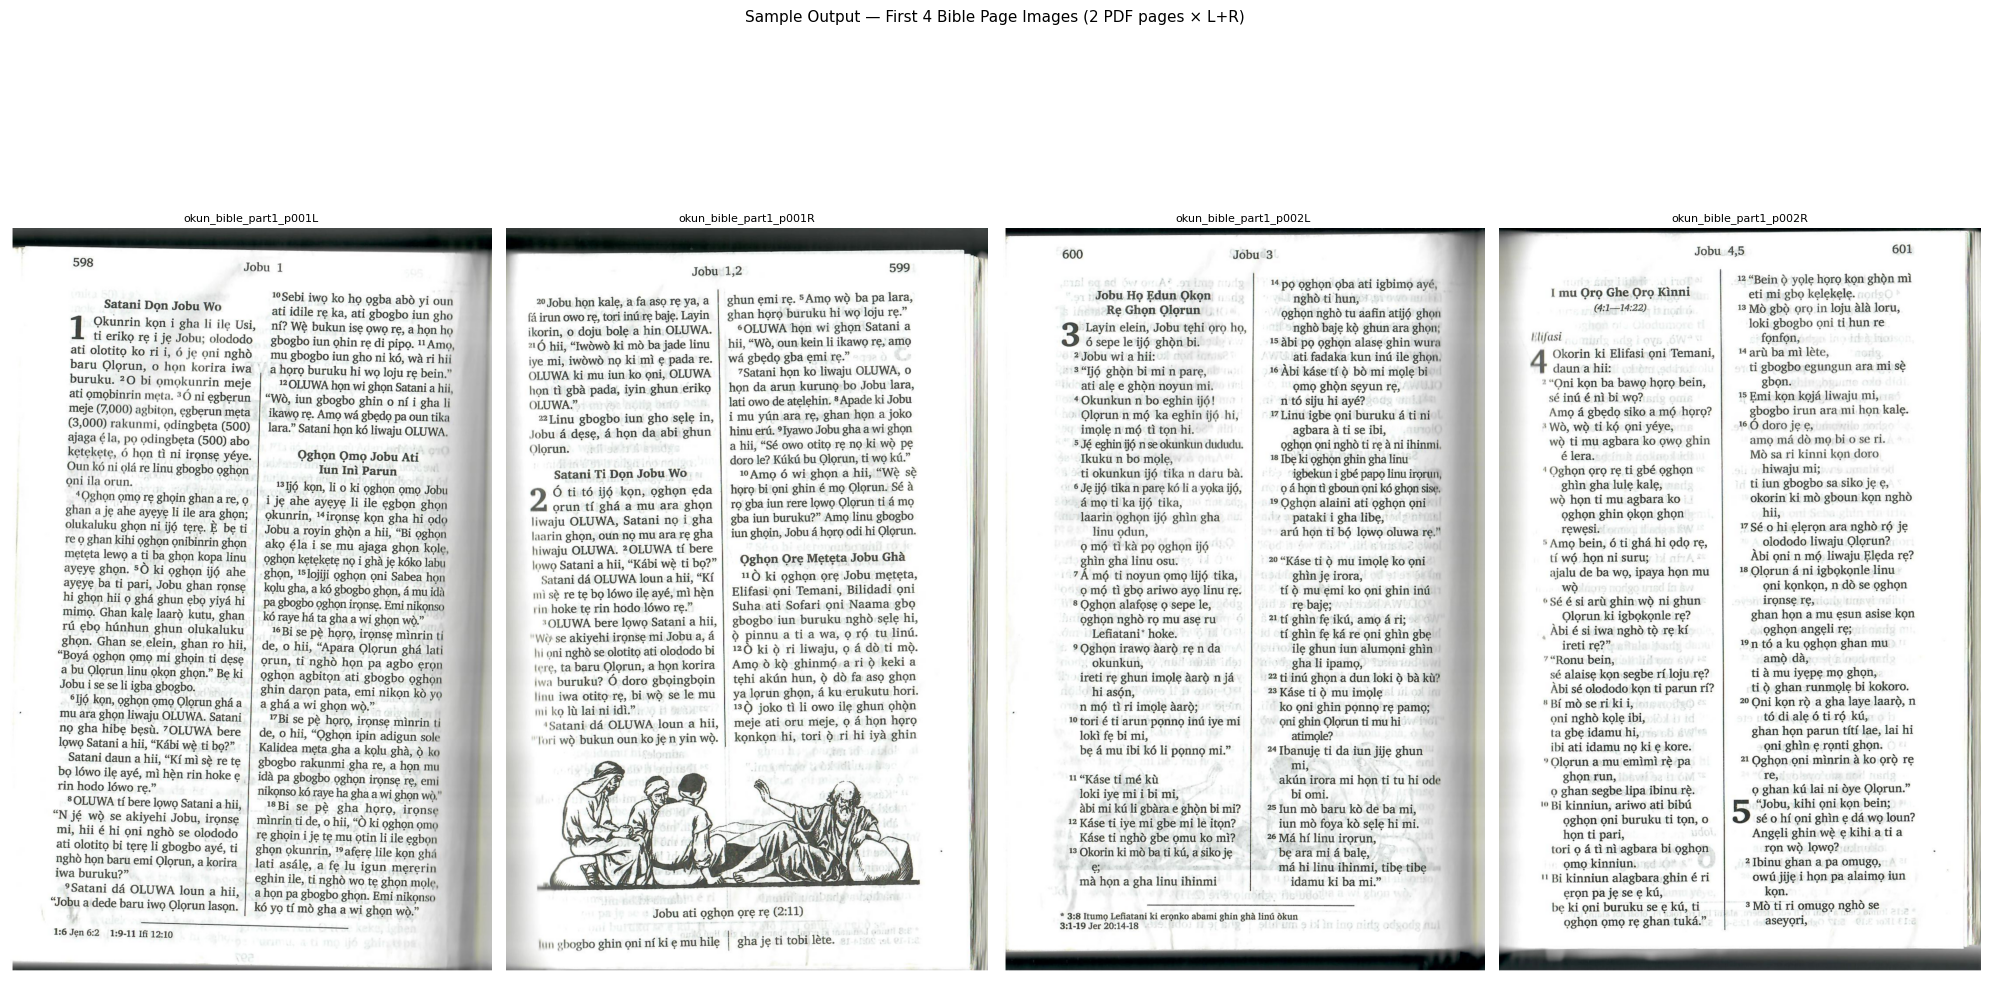


OCR text preview (first 200 chars):

okun_bible_part1_p001L:
(no txt file — run Step 5 or add your own)

okun_bible_part1_p001R:
(no txt file — run Step 5 or add your own)

okun_bible_part1_p002L:
(no txt file — run Step 5 or add your own)

okun_bible_part1_p002R:
(no txt file — run Step 5 or add your own)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

preview = extracted_pages[:4]  # first 2 PDF pages = 4 bible page images

if not preview:
    print('No output images found. Run Step 4 first.')
else:
    fig, axes = plt.subplots(1, len(preview), figsize=(20, 12))
    if len(preview) == 1:
        axes = [axes]

    for ax, (page_id, png_path) in zip(axes, preview):
        img = mpimg.imread(str(png_path))
        ax.imshow(img, cmap='gray')
        ax.set_title(page_id, fontsize=8)
        ax.axis('off')

    plt.suptitle('Sample Output — First 4 Bible Page Images (2 PDF pages × L+R)', fontsize=11)
    plt.tight_layout()
    plt.show()

    # Show txt preview if available
    print('\nOCR text preview (first 200 chars):')
    print('=' * 55)
    for page_id, _ in preview:
        txt_path = Path(OUTPUT_DIR) / f'{page_id}.txt'
        txt = txt_path.read_text(encoding='utf-8')[:200] if txt_path.exists() else '(no txt file — run Step 5 or add your own)'
        print(f'\n{page_id}:\n{txt}')


## Step 7 — Verify Output File List

Checks that every `.png` has a matching `.txt` file and reports any gaps.


In [ ]:
import glob, os
from pathlib import Path

pngs = sorted(glob.glob(str(Path(OUTPUT_DIR) / '*.png')))
txts = sorted(glob.glob(str(Path(OUTPUT_DIR) / '*.txt')))

print(f'Output directory : {OUTPUT_DIR}')
print(f'PNG images       : {len(pngs)}')
print(f'TXT files        : {len(txts)}')
print()

# Check every PNG has a matching txt
missing_txt = []
for png in pngs:
    page_id  = Path(png).stem
    txt_path = Path(OUTPUT_DIR) / f'{page_id}.txt'
    if not txt_path.exists():
        missing_txt.append(page_id)

if missing_txt:
    print(f'WARNING — {len(missing_txt)} images have no matching .txt file:')
    for p in missing_txt:
        print(f'  {p}')
    print('\nEither run Step 5 (OCR) or copy your existing .txt files into OUTPUT_DIR.')
else:
    print('Every image has a matching .txt file.')
    print('Ready to run the Okun Bible Chapter Cleaner notebook.')

# Sample listing
print(f'\nFirst 10 files:')
for png in pngs[:10]:
    page_id = Path(png).stem
    png_kb  = os.path.getsize(png) // 1024
    txt_path = Path(OUTPUT_DIR) / f'{page_id}.txt'
    txt_b   = os.path.getsize(str(txt_path)) if txt_path.exists() else 0
    txt_status = f'{txt_b}B' if txt_b else 'MISSING'
    print(f'  {page_id:40s}  png:{png_kb:5d}KB  txt:{txt_status}')

if len(pngs) > 10:
    print(f'  ... and {len(pngs)-10} more')


Output directory : /content/drive/MyDrive/Colab Notebooks/Okun digitization/images
PNG images       : 356
TXT files        : 0

WARNING — 356 images have no matching .txt file:
  okun_bible_part1_p001L
  okun_bible_part1_p001R
  okun_bible_part1_p002L
  okun_bible_part1_p002R
  okun_bible_part1_p003L
  okun_bible_part1_p003R
  okun_bible_part1_p004L
  okun_bible_part1_p004R
  okun_bible_part1_p005L
  okun_bible_part1_p005R
  okun_bible_part1_p006L
  okun_bible_part1_p006R
  okun_bible_part1_p007L
  okun_bible_part1_p007R
  okun_bible_part1_p008L
  okun_bible_part1_p008R
  okun_bible_part1_p009L
  okun_bible_part1_p009R
  okun_bible_part1_p010L
  okun_bible_part1_p010R
  okun_bible_part1_p011L
  okun_bible_part1_p011R
  okun_bible_part1_p012L
  okun_bible_part1_p012R
  okun_bible_part1_p013L
  okun_bible_part1_p013R
  okun_bible_part1_p014L
  okun_bible_part1_p014R
  okun_bible_part1_p015L
  okun_bible_part1_p015R
  okun_bible_part1_p016L
  okun_bible_part1_p016R
  okun_bible_part1_p017

---
## Notes

**Rotation:** The PDFs are portrait but contain landscape scans rotated 90° clockwise.
The extractor corrects this with a 90° counter-clockwise rotation before splitting.
If your preview (Step 6) shows text upside-down, change `img.rotate(90` to `img.rotate(-90` in Step 4.

**Already have .txt files?** Skip Step 5 (OCR). Your existing `p001L.txt` / `p001R.txt`
files match the `p001L.png` / `p001R.png` images by name automatically.

**Page numbering across multiple PDFs:** Set `start_page_number` so numbers don't overlap.
Example: PDF1 has 94 pages → uses p001–p094. Set PDF2 start to 95, PDF3 to wherever PDF2 ends + 1.

**Connecting to the Cleaner notebook:** In the Cleaner's Cell 3, set:
```python
PAGES_FOLDER = '<same value as OUTPUT_DIR above>'
```

**Split cuts through text instead of the gutter?** Adjust the midpoint in Step 4:
change `mid = w // 2` to `mid = w // 2 + 20` (or `-20`) to shift the cut left or right.
